In [2]:
import pandas as pd 
import sqlite3

In [3]:
df = pd.read_csv('Details.csv')
df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card
...,...,...,...,...,...,...,...
1495,B-25700,7,-3,2,Clothing,Hankerchief,COD
1496,B-25757,3151,-35,7,Clothing,Trousers,EMI
1497,B-25973,4141,1698,13,Electronics,Printers,COD
1498,B-25698,7,-2,1,Clothing,Hankerchief,COD


In [4]:
conn = sqlite3.connect('sales.db')
df.to_sql('Sales', conn , if_exists = 'replace', index = False)
print(f'The CSV is converted to SQL Database as {'Sales'} Table')

 

The CSV is converted to SQL Database as Sales Table


In [5]:
cursor = conn.cursor()
cursor.execute("SELECT * FROM Sales LIMIT 10;")
rows = cursor.fetchall()

for row in rows:
    print(row)


('B-25681', 1096, 658, 7, 'Electronics', 'Electronic Games', 'COD')
('B-26055', 5729, 64, 14, 'Furniture', 'Chairs', 'EMI')
('B-25955', 2927, 146, 8, 'Furniture', 'Bookcases', 'EMI')
('B-26093', 2847, 712, 8, 'Electronics', 'Printers', 'Credit Card')
('B-25602', 2617, 1151, 4, 'Electronics', 'Phones', 'Credit Card')
('B-25881', 2244, 247, 4, 'Clothing', 'Trousers', 'Credit Card')
('B-25696', 275, -275, 4, 'Clothing', 'Saree', 'COD')
('B-25687', 387, -213, 5, 'Clothing', 'Saree', 'UPI')
('B-25643', 50, -44, 2, 'Clothing', 'Hankerchief', 'UPI')
('B-25851', 135, -54, 5, 'Clothing', 'Kurti', 'COD')


In [6]:
cursor = conn.cursor()
cursor.execute("SELECT SUM(Quantity) as total_quantity_sold FROM Sales;")
total_quantity_sold = cursor.fetchone()[0]

print(f'Total Quantity Sold: {total_quantity_sold}')


Total Quantity Sold: 5615


In [7]:
cursor = conn.cursor()
cursor.execute("""
SELECT Category , SUM(Quantity) as Highest_Category_Sold
FROM Sales
GROUP BY Category
ORDER BY Highest_Category_Sold DESC
LIMIT 1
""")

top_category = cursor.fetchone()
print(f"Best Sold Category: {top_category[0]}")


Best Sold Category: Clothing


In [8]:
cursor = conn.cursor()
cursor.execute("""
SELECT 
SUM(Amount) as Total_revenue_generated
FROM Sales;
""")
total_revenue_generated = cursor.fetchone()[0]
print(f'Total Revenue Generated : {total_revenue_generated}')


Total Revenue Generated : 437771


In [9]:
cursor = conn.cursor()
cursor.execute("""
SELECT 
AVG(Profit) as profit_per_sale ,
SUM(Profit) as overall_profit

FROM Sales;
""")
result = cursor.fetchone()
profit_per_sale = result[0]
overall_profit = result[1]
print(f'Profit per sale:{profit_per_sale:.2f} and Overall profit:{overall_profit:.2f}')

Profit per sale:24.64 and Overall profit:36963.00


In [10]:
import matplotlib.pyplot as plt 

cursor = conn.cursor()
cursor.execute("""
SELECT
Category,
SUM(Amount)
FROM Sales
GROUP BY Category;

""")
results = cursor.fetchall()


In [11]:
results

[('Clothing', 144323), ('Electronics', 166267), ('Furniture', 127181)]

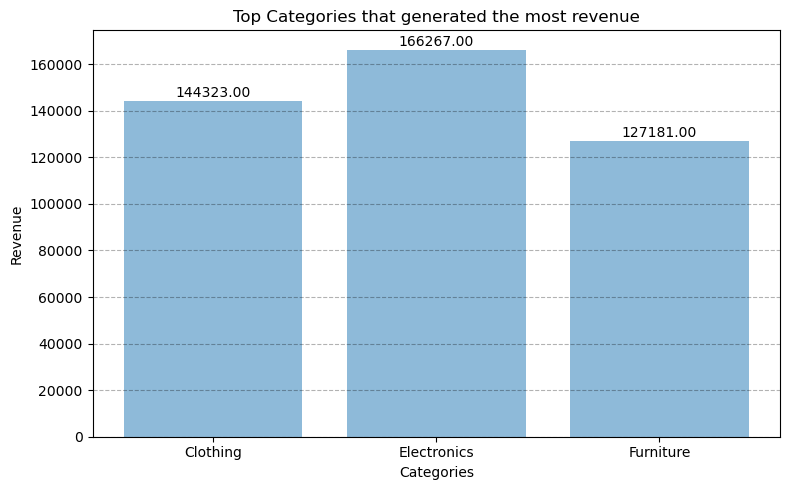

In [12]:
if results and len(results[0]) == 2 :
    categories = [row[0] for row in results]
    revenues = [row[1] for row in results]

    plt.figure(figsize =(8,5))
    plt.bar(categories, revenues ,alpha = 0.5)
    plt.title('Top Categories that generated the most revenue')
    plt.ylabel('Revenue')
    plt.xlabel('Categories')
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.3, color = 'Black')

    for i , v in enumerate(revenues):
         plt.text(i,v+max(revenues)*0.01, f'{v:.2f}', ha = 'center')
       

    plt.tight_layout()
    plt.show()
else:
    print("No data returned or malformed rows")


In [13]:
conn.close()